# 🛒 Blinkit Sales & Outlet Performance Analysis

## 📊 SQL + Python Data Analytics Project

### Project Objective
This project analyzes Blinkit's grocery sales data to identify key patterns in product performance, outlet performance, sales distribution, and business trends.

### Tools & Technologies
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- MySQL
- Jupyter Notebook

### Key Business Areas
- Product & Category Performance
- Outlet Performance
- Location-wise Sales
- Item Fat Content Analysis
- Sales & Rating Analysis
- Item Visibility Analysis
- Sales Trends
- Top-performing Products

### Dataset
- **8,523 records**
- **1,559 unique products**
- **16 product categories**
- **10 outlets**
- **3 location tiers**
- **4 outlet types**

### Important Note
`Sales` represents sales value at the individual dataset-record level. Therefore, metrics such as Average Order Value (AOV), customer count, and order-level behavior are not calculated because the dataset does not contain Order ID or Customer ID.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Libraries imported successfully!


## 1. Data Loading & Initial Inspection

The dataset is loaded using Pandas and inspected for structure, data types, missing values, and duplicate records.

In [2]:
df = pd.read_csv("blinkit.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (8523, 11)


In [3]:
df.head()

,Item Fat Content,Item Identifier,Item Type,Outlet Establishment Year,Outlet Identifier,Outlet Location Type,Outlet Size,Outlet Type,Item Visibility,Sales,Rating
0,Regular,FDX32,Fruits and Vegetables,2012,OUT049,Tier 1,Medium,Supermarket Type1,0.100014,145.4786,5.0
1,Low Fat,NCB42,Health and Hygiene,2022,OUT018,Tier 3,Medium,Supermarket Type2,0.008596,115.3492,5.0
2,Regular,FDR28,Frozen Foods,2016,OUT046,Tier 1,Small,Supermarket Type1,0.025896,165.0210,5.0
3,Regular,FDL50,Canned,2014,OUT013,Tier 3,High,Supermarket Type1,0.042278,126.5046,5.0
4,Low Fat,DRI25,Soft Drinks,2015,OUT045,Tier 2,Small,Supermarket Type1,0.033970,55.1614,5.0


In [5]:
print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicated Values:")
print(df.duplicated().sum())

Dataset Shape: (8523, 11)

Column Names:
['Item Fat Content', 'Item Identifier', 'Item Type', 'Outlet Establishment Year', 'Outlet Identifier', 'Outlet Location Type', 'Outlet Size', 'Outlet Type', 'Item Visibility', 'Sales', 'Rating']

Data Types:
Item Fat Content                 str
Item Identifier                  str
Item Type                        str
Outlet Establishment Year      int64
Outlet Identifier                str
Outlet Location Type             str
Outlet Size                      str
Outlet Type                      str
Item Visibility              float64
Sales                        float64
Rating                       float64
dtype: object

Missing Values:
Item Fat Content             0
Item Identifier              0
Item Type                    0
Outlet Establishment Year    0
Outlet Identifier            0
Outlet Location Type         0
Outlet Size                  0
Outlet Type                  0
Item Visibility              0
Sales                        0
Rat

## 2. Data Cleaning & Standardization

The dataset was checked for missing values, duplicate records, invalid numeric values, and inconsistent categorical labels.

The `Item Fat Content` column contained multiple labels representing the same categories. These values were standardized into two consistent categories:
- Low Fat
- Regular

### Duplicate Record Check

Duplicate records were checked to ensure that the dataset does not contain repeated rows that could distort sales analysis and business insights.

The dataset contains **0 duplicate records**, confirming that each row is unique based on all available columns.

In [9]:
duplicate_count = df.duplicated().sum()

print("Duplicate Rows:", duplicate_count)

Duplicate Rows: 0


In [7]:
df['Item Fat Content'] = df['Item Fat Content'].replace({
    'LF': 'Low Fat',
    'low fat': 'Low Fat',
    'reg': 'Regular',
    'regular': 'Regular'
})

print(df['Item Fat Content'].value_counts())

Item Fat Content
Low Fat    5517
Regular    3006
Name: count, dtype: int64


### Categorical Variables Analysis

Categorical variables were examined to understand the distribution of products, outlets, location tiers, outlet sizes, and item characteristics.

The main categorical variables include:

- **Item Fat Content** — Low Fat, Regular
- **Item Type** — 16 product categories
- **Outlet Location Type** — Tier 1, Tier 2, Tier 3
- **Outlet Size** — Small, Medium, High
- **Outlet Type** — Grocery Store, Supermarket Type1, Supermarket Type2, Supermarket Type3

These variables were analyzed using frequency counts and were later used for category-wise and outlet-wise sales comparisons.

In [8]:
categorical_columns = [
    'Item Fat Content',
    'Item Type',
    'Outlet Location Type',
    'Outlet Size',
    'Outlet Type'
]

for column in categorical_columns:
    print(f"\n--- {column} ---")
    print(df[column].value_counts())


--- Item Fat Content ---
Item Fat Content
Low Fat    5517
Regular    3006
Name: count, dtype: int64

--- Item Type ---
Item Type
Fruits and Vegetables    1232
Snack Foods              1200
Household                 910
Frozen Foods              856
Dairy                     682
Canned                    649
Baking Goods              648
Health and Hygiene        520
Soft Drinks               445
Meat                      425
Breads                    251
Hard Drinks               214
Others                    169
Starchy Foods             148
Breakfast                 110
Seafood                    64
Name: count, dtype: int64

--- Outlet Location Type ---
Outlet Location Type
Tier 3    3350
Tier 2    2785
Tier 1    2388
Name: count, dtype: int64

--- Outlet Size ---
Outlet Size
Medium    3631
Small     3139
High      1753
Name: count, dtype: int64

--- Outlet Type ---
Outlet Type
Supermarket Type1    5577
Grocery Store        1083
Supermarket Type3     935
Supermarket Type2     928
N

## 3. Descriptive Statistics

Descriptive statistics are used to understand the central tendency, spread, and range of the key numerical variables in the dataset.

In [12]:
df.describe()

,Outlet Establishment Year,Item Visibility,Sales,Rating
count,8523.000000,8523.000000,8523.000000,8523.000000
mean,2016.450546,0.066132,140.992783,3.965857
std,3.189396,0.051598,62.275067,0.605651
min,2011.000000,0.000000,31.290000,1.000000
25%,2014.000000,0.026989,93.826500,4.000000
50%,2016.000000,0.053931,143.012800,4.000000
75%,2018.000000,0.094585,185.643700,4.200000
max,2022.000000,0.328391,266.888400,5.000000


## 4. Exploratory Data Analysis (EDA)

This section explores sales performance across product categories, outlet types, location tiers, outlet sizes, and item characteristics.

### 4.1 Sales by Item Type

Fruits and Vegetables and Snack Foods are among the highest contributors to total sales, while Seafood contributes the least.

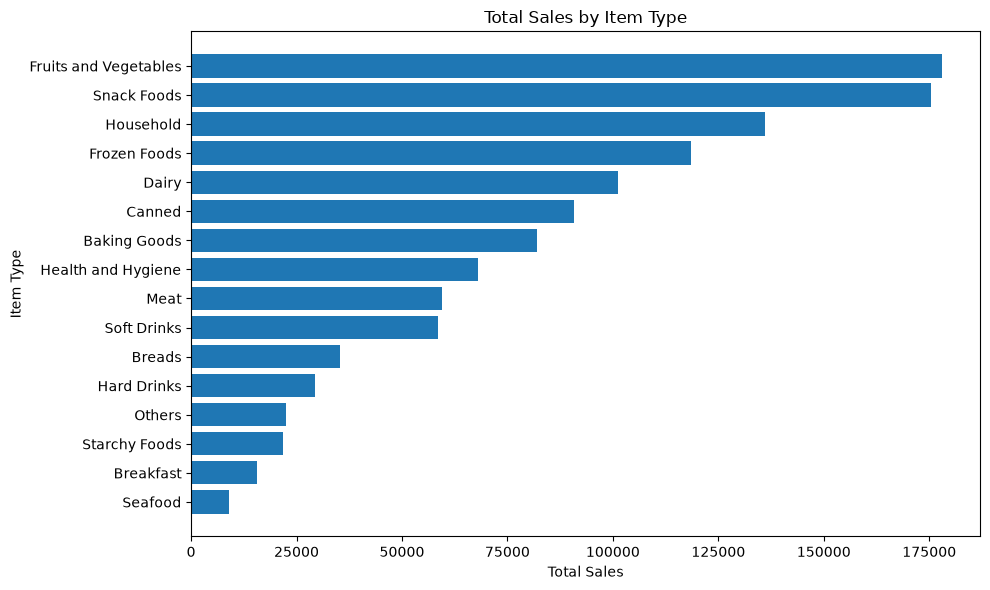

In [13]:
category_sales = (
    df.groupby('Item Type')['Sales']
      .sum()
      .sort_values(ascending=True)
)

plt.figure(figsize=(10, 6))
plt.barh(category_sales.index, category_sales.values)

plt.title('Total Sales by Item Type')
plt.xlabel('Total Sales')
plt.ylabel('Item Type')
plt.tight_layout()

plt.show()

### Sales Contribution by Item Category

This analysis measures the percentage contribution of each item category to the overall sales generated in the dataset.

It helps identify which product categories contribute the largest share of total sales and highlights the concentration of sales across different categories.

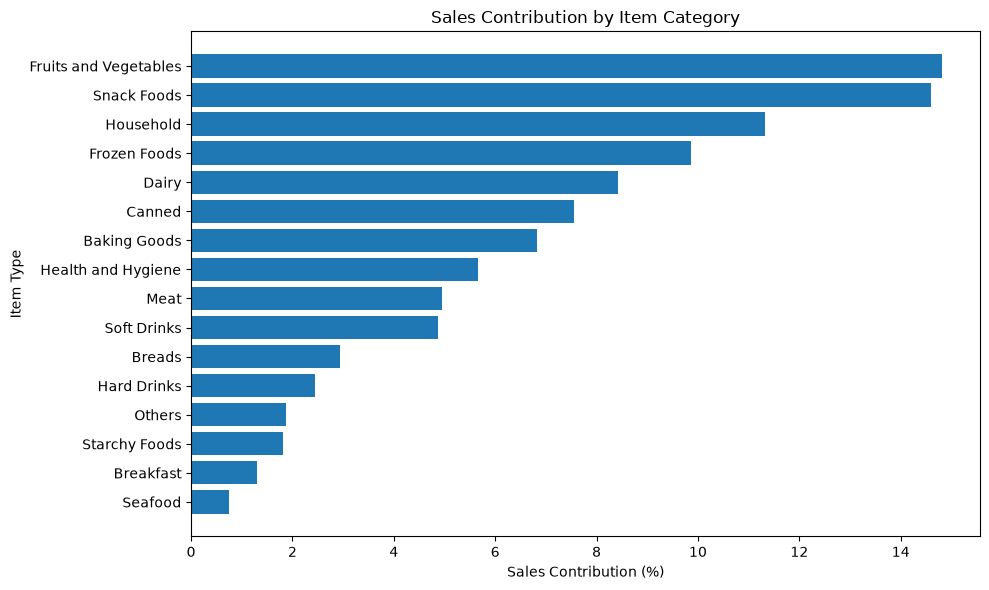

In [36]:
category_sales = (
    df.groupby('Item Type')['Sales']
      .sum()
      .sort_values(ascending=False)
)

category_percentage = (
    category_sales / category_sales.sum() * 100
)

plt.figure(figsize=(10, 6))
plt.barh(
    category_percentage.index[::-1],
    category_percentage.values[::-1]
)

plt.title('Sales Contribution by Item Category')
plt.xlabel('Sales Contribution (%)')
plt.ylabel('Item Type')

plt.tight_layout()
plt.show()


### 4.2 Sales by Outlet Type

Supermarket Type1 contributes the largest share of total sales, while the other outlet types contribute smaller but meaningful portions.

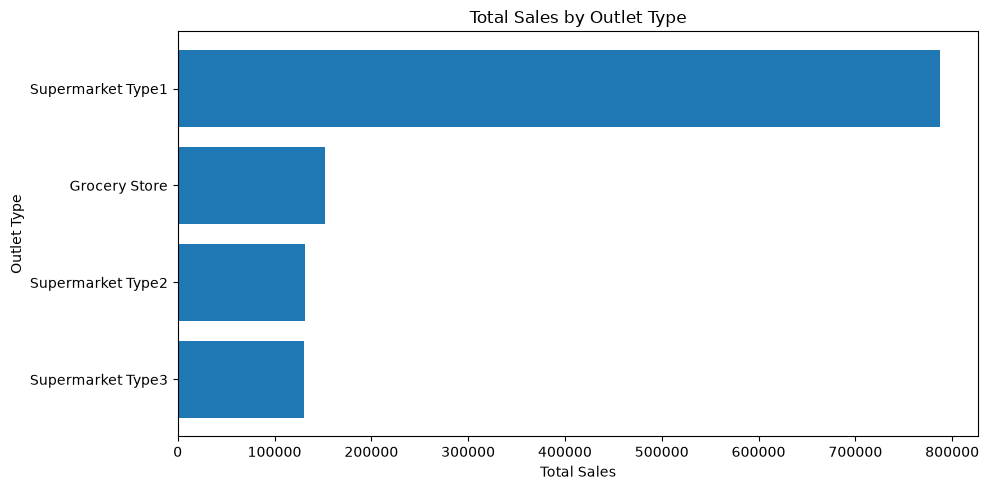

In [14]:
outlet_sales = (
    df.groupby('Outlet Type')['Sales']
      .sum()
      .sort_values(ascending=True)
)

plt.figure(figsize=(10, 5))
plt.barh(outlet_sales.index, outlet_sales.values)

plt.title('Total Sales by Outlet Type')
plt.xlabel('Total Sales')
plt.ylabel('Outlet Type')
plt.tight_layout()

plt.show()

### 4.3 Sales by Outlet Location Tier

Tier 3 outlets generate the highest total sales, followed by Tier 2 and Tier 1. The difference in average sales per record across tiers is relatively small.

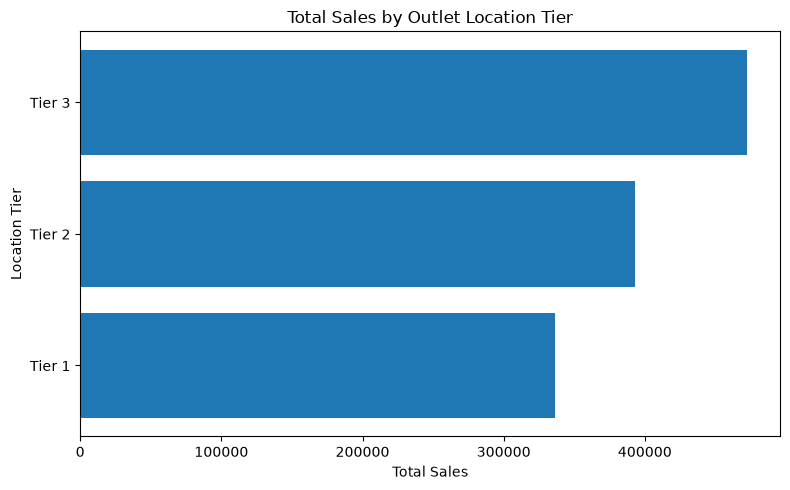

In [15]:
location_sales = (
    df.groupby('Outlet Location Type')['Sales']
      .sum()
      .sort_values(ascending=True)
)

plt.figure(figsize=(8, 5))
plt.barh(location_sales.index, location_sales.values)

plt.title('Total Sales by Outlet Location Tier')
plt.xlabel('Total Sales')
plt.ylabel('Location Tier')
plt.tight_layout()

plt.show()

### 4.4 Sales by Outlet Size

Medium-sized outlets generate the highest total sales, largely reflecting their larger number of records. High-sized outlets have the highest average sales per record.

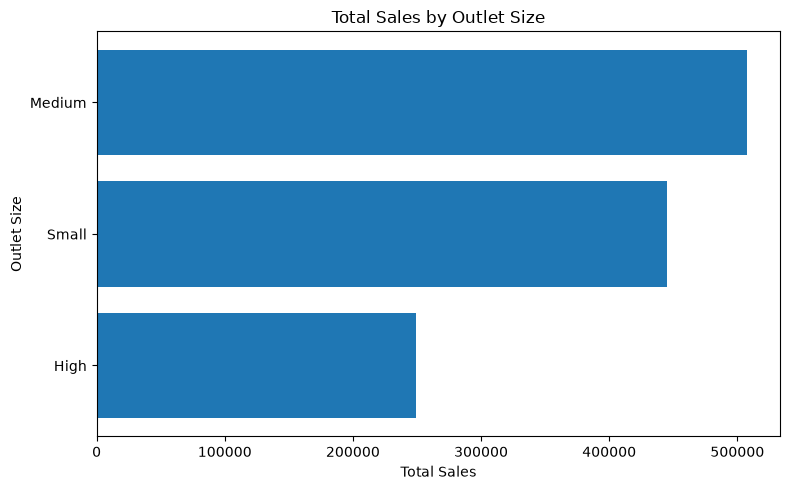

In [16]:
size_sales = (
    df.groupby('Outlet Size')['Sales']
      .sum()
      .sort_values(ascending=True)
)

plt.figure(figsize=(8, 5))
plt.barh(size_sales.index, size_sales.values)

plt.title('Total Sales by Outlet Size')
plt.xlabel('Total Sales')
plt.ylabel('Outlet Size')
plt.tight_layout()

plt.show()

### 4.5 Sales by Item Fat Content

Low Fat products contribute more total sales than Regular products. However, this is influenced by the higher number of Low Fat records in the dataset, so total sales alone should not be interpreted as stronger per-record performance.

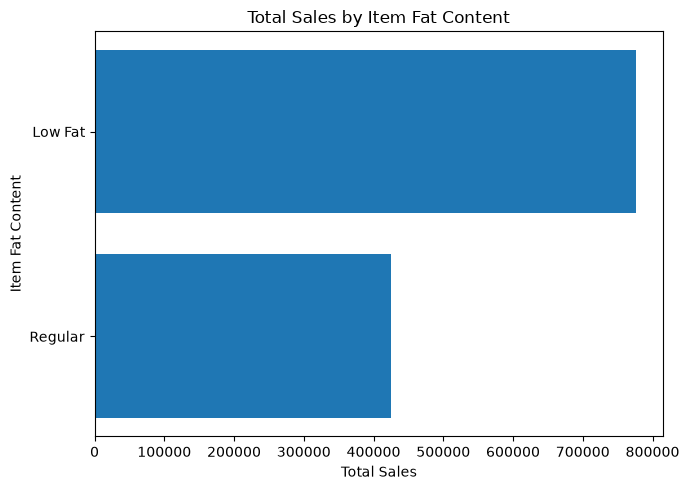

In [17]:
fat_sales = (
    df.groupby('Item Fat Content')['Sales']
      .sum()
      .sort_values(ascending=True)
)

plt.figure(figsize=(7, 5))
plt.barh(fat_sales.index, fat_sales.values)

plt.title('Total Sales by Item Fat Content')
plt.xlabel('Total Sales')
plt.ylabel('Item Fat Content')
plt.tight_layout()

plt.show()

### Sales by Item Fat Content (%)

This analysis compares the percentage contribution of total sales between Low Fat and Regular products.

It helps understand the sales mix by item fat content and shows which product segment contributes a larger share of overall sales.

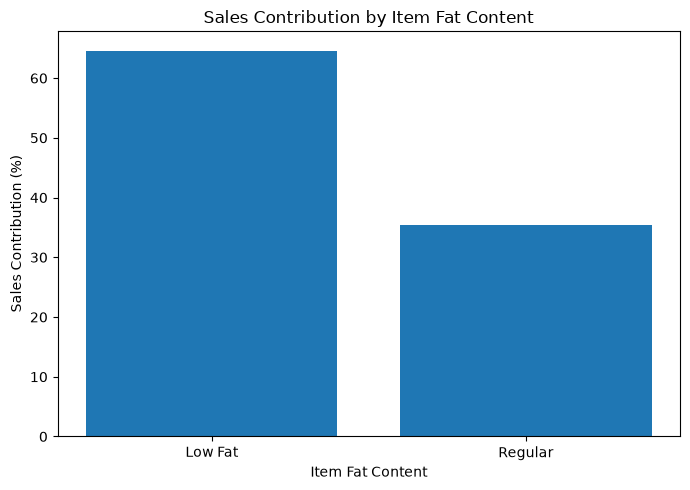

In [18]:
fat_sales = (
    df.groupby('Item Fat Content')['Sales']
      .sum()
      .sort_values(ascending=False)
)

fat_percentage = fat_sales / fat_sales.sum() * 100

plt.figure(figsize=(7, 5))

plt.bar(
    fat_percentage.index,
    fat_percentage.values
)

plt.title('Sales Contribution by Item Fat Content')
plt.xlabel('Item Fat Content')
plt.ylabel('Sales Contribution (%)')

plt.tight_layout()
plt.show()

### 4.6 Average Sales per Record by Item Type

Household has the highest average sales per record among the item categories, while Baking Goods has the lowest. This metric complements total sales by accounting for differences in record volume.

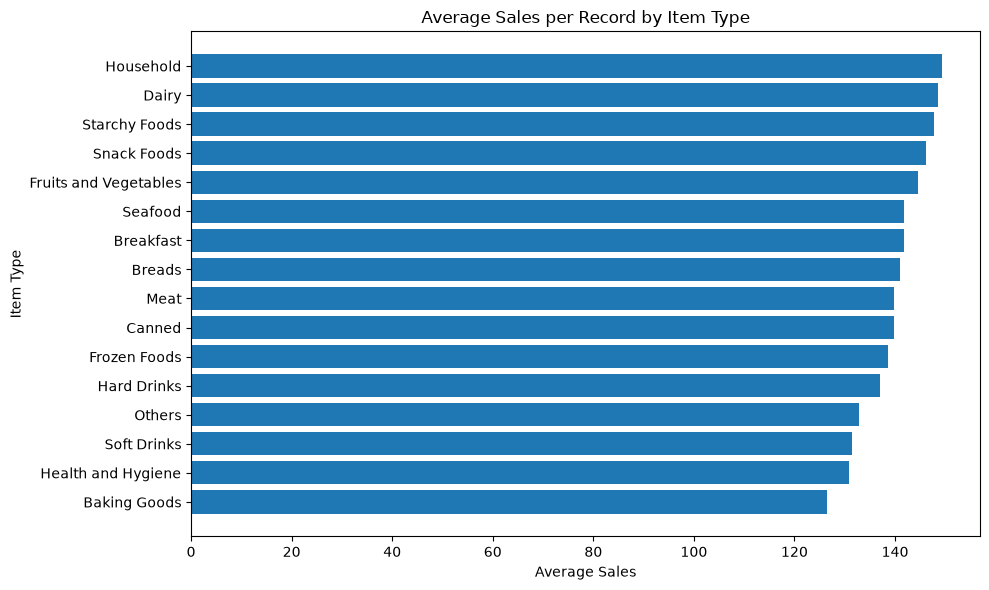

In [19]:
avg_category_sales = (
    df.groupby('Item Type')['Sales']
      .mean()
      .sort_values(ascending=True)
)

plt.figure(figsize=(10, 6))
plt.barh(avg_category_sales.index, avg_category_sales.values)

plt.title('Average Sales per Record by Item Type')
plt.xlabel('Average Sales')
plt.ylabel('Item Type')
plt.tight_layout()

plt.show()

### 4.8 Rating vs Sales

The scatter plot helps examine whether higher-rated records are associated with higher sales. The relationship is not expected to be interpreted as causal.

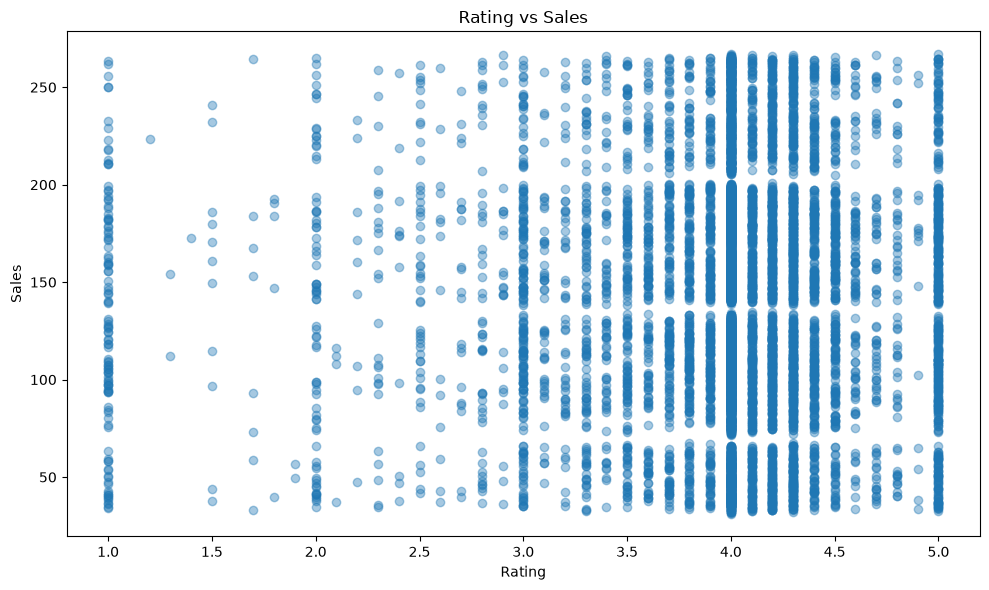

In [21]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df['Rating'],
    df['Sales'],
    alpha=0.4
)

plt.title('Rating vs Sales')
plt.xlabel('Rating')
plt.ylabel('Sales')

plt.tight_layout()
plt.show()

### 4.7 Item Visibility vs Sales

The scatter plot shows how sales values are distributed across different levels of item visibility. The relationship does not appear to follow a simple strong linear pattern.

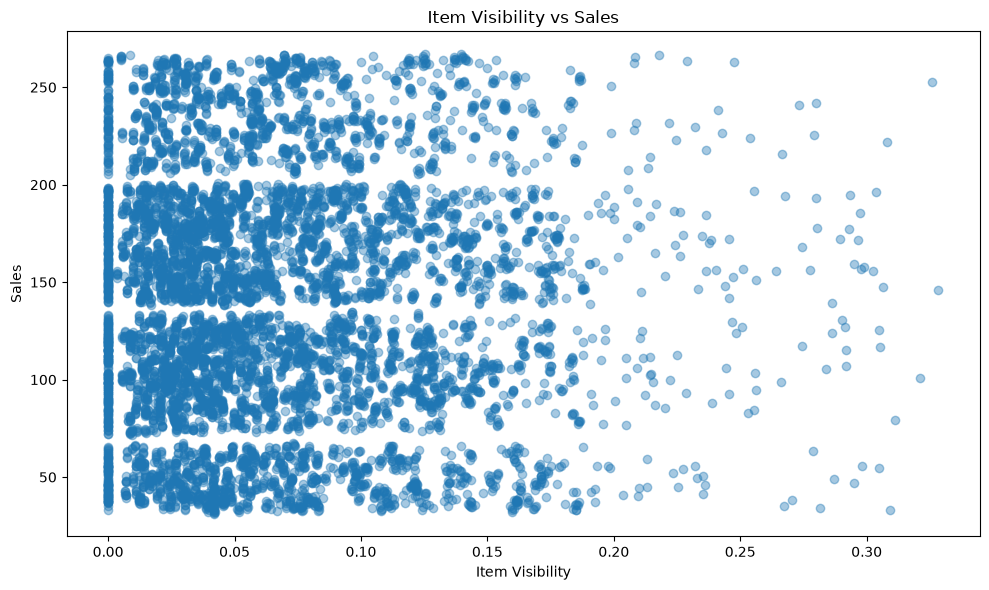

In [22]:
plt.figure(figsize=(10, 6))

plt.scatter(
    df['Item Visibility'],
    df['Sales'],
    alpha=0.4
)

plt.title('Item Visibility vs Sales')
plt.xlabel('Item Visibility')
plt.ylabel('Sales')

plt.tight_layout()
plt.show()

### 4.9 Sales Trend by Outlet Establishment Year

This analysis compares total sales across outlet establishment years. The trend should be interpreted alongside the number of records, since years with more outlet records can naturally have higher total sales.


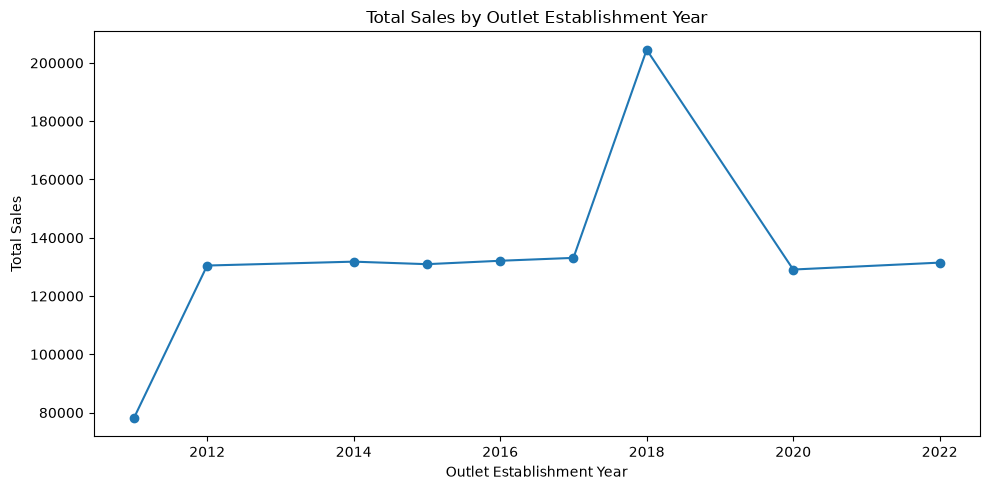

In [23]:
year_sales = (
    df.groupby('Outlet Establishment Year')['Sales']
      .sum()
      .sort_index()
)

plt.figure(figsize=(10, 5))

plt.plot(
    year_sales.index,
    year_sales.values,
    marker='o'
)

plt.title('Total Sales by Outlet Establishment Year')
plt.xlabel('Outlet Establishment Year')
plt.ylabel('Total Sales')

plt.tight_layout()
plt.show()

### 4.10 Top 10 Products by Total Sales

The following analysis identifies the individual products generating the highest total sales within the dataset.

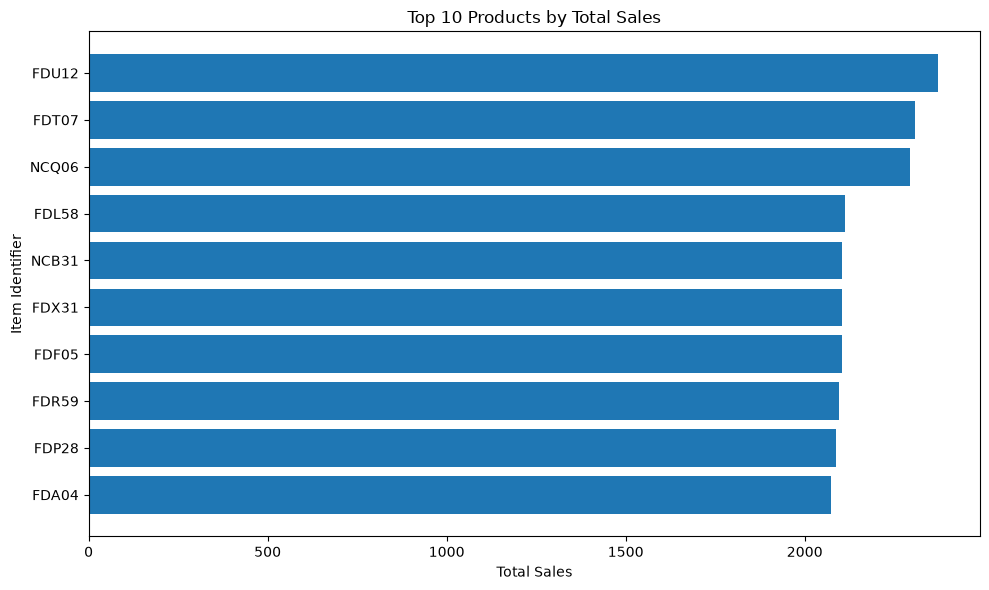

In [24]:
top_products = (
    df.groupby('Item Identifier')['Sales']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(10, 6))
plt.barh(
    top_products.index[::-1],
    top_products.values[::-1]
)

plt.title('Top 10 Products by Total Sales')
plt.xlabel('Total Sales')
plt.ylabel('Item Identifier')

plt.tight_layout()
plt.show()

### 4.12 Top 10 Products with Category

This analysis identifies the top 10 individual products based on total sales and displays their corresponding product categories.

The analysis helps identify specific high-performing products and the categories they belong to, providing a more detailed view of product-level sales performance.

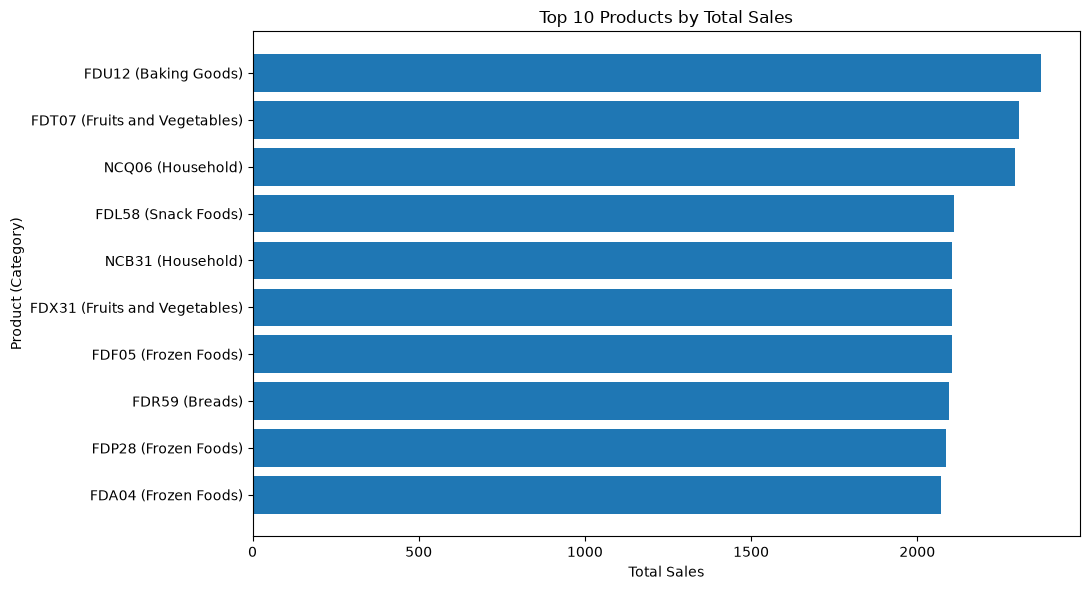

In [25]:
top_products = (
    df.groupby(['Item Identifier', 'Item Type'])['Sales']
      .sum()
      .sort_values(ascending=False)
      .head(10)
      .sort_values()
)

labels = [
    f"{product} ({category})"
    for product, category in top_products.index
]

plt.figure(figsize=(11, 6))
plt.barh(labels, top_products.values)

plt.title('Top 10 Products by Total Sales')
plt.xlabel('Total Sales')
plt.ylabel('Product (Category)')

plt.tight_layout()
plt.show()

### 4.11 Sales Distribution

The sales distribution shows how individual record-level sales values are spread across the dataset and helps identify the most common sales ranges.

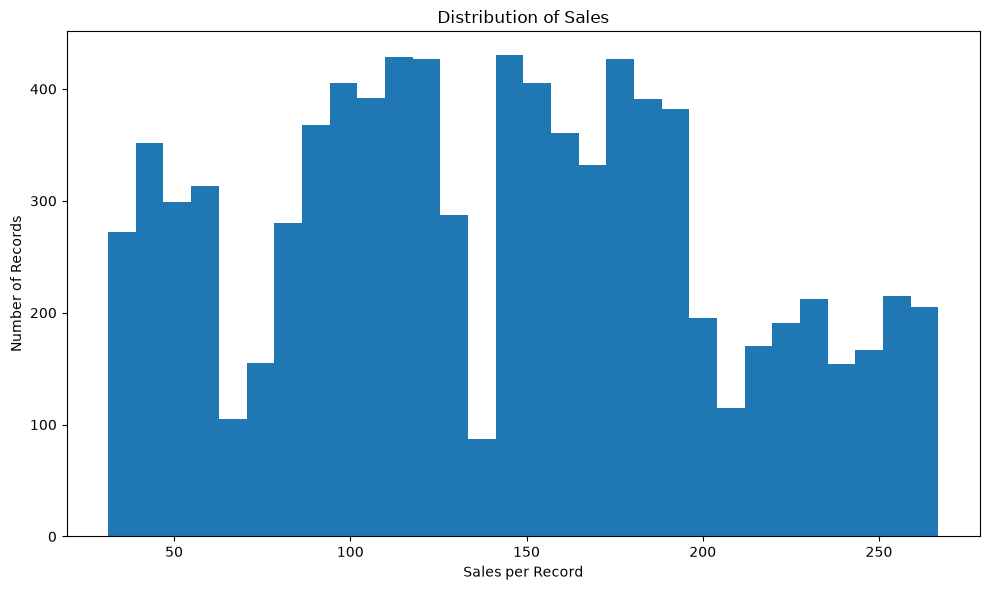

In [26]:
plt.figure(figsize=(10, 6))

plt.hist(
    df['Sales'],
    bins=30
)

plt.title('Distribution of Sales')
plt.xlabel('Sales per Record')
plt.ylabel('Number of Records')

plt.tight_layout()
plt.show()

### Correlation Analysis

Correlation analysis helps identify the strength and direction of linear relationships between the key numerical variables.

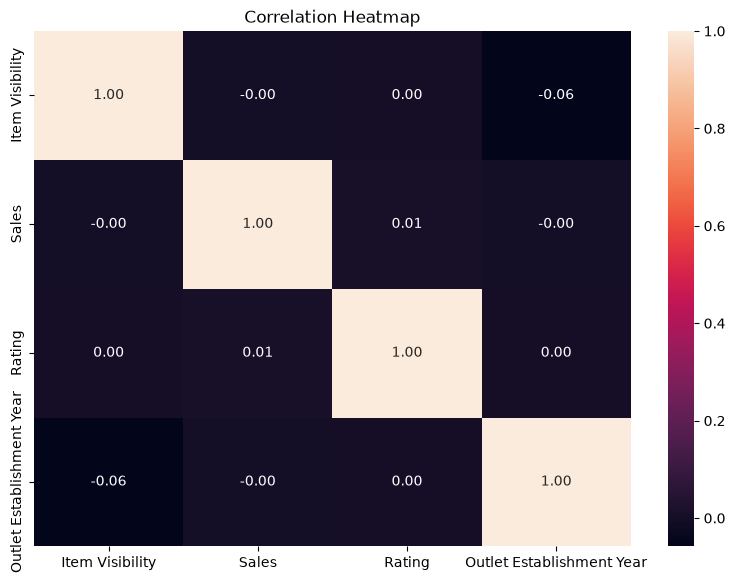

In [27]:
corr = df[['Item Visibility', 'Sales', 'Rating', 'Outlet Establishment Year']].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f')

plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

### Sales by Outlet Type and Location Tier

This analysis compares sales performance across different outlet types and location tiers.

It helps identify which combinations of outlet format and market tier generate higher total sales and provides a deeper understanding of outlet performance across different locations.

<Figure size 1000x600 with 0 Axes>

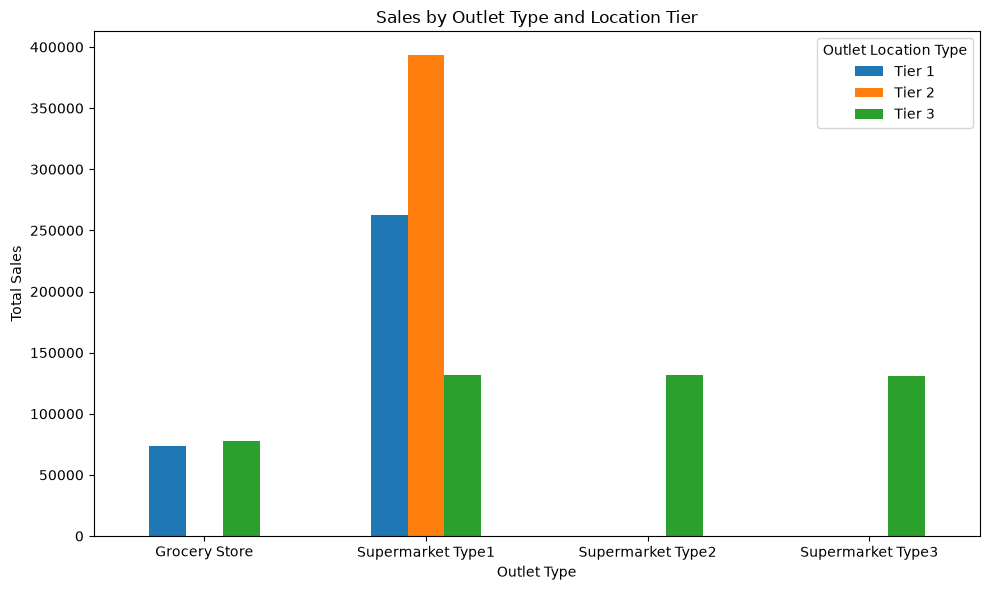

In [28]:
outlet_location_sales = (
    df.groupby(['Outlet Type', 'Outlet Location Type'])['Sales']
      .sum()
      .unstack()
)

plt.figure(figsize=(10, 6))

outlet_location_sales.plot(
    kind='bar',
    figsize=(10, 6)
)

plt.title('Sales by Outlet Type and Location Tier')
plt.xlabel('Outlet Type')
plt.ylabel('Total Sales')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### Average Sales by Outlet Type

This analysis compares the average sales per record across different outlet types.

It helps identify which outlet formats show stronger per-record sales performance, independent of the total number of records associated with each outlet type.

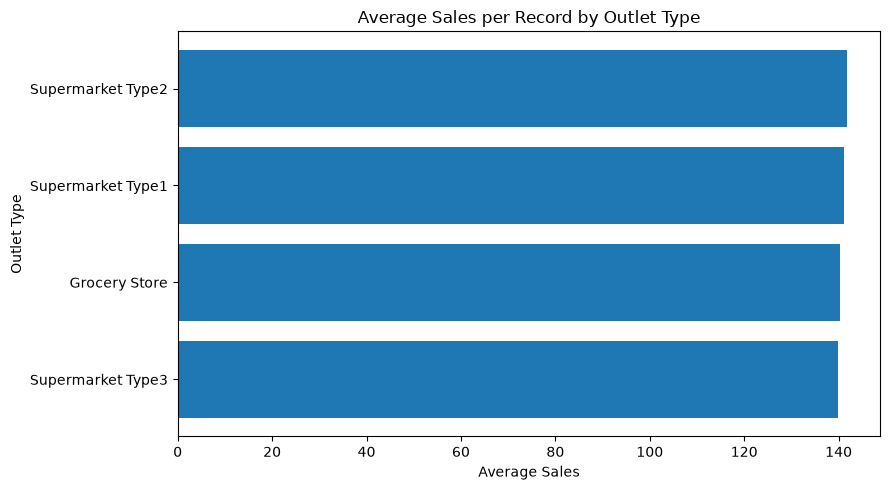

In [29]:

avg_outlet_sales = (
    df.groupby('Outlet Type')['Sales']
      .mean()
      .sort_values(ascending=True)
)

plt.figure(figsize=(9, 5))

plt.barh(
    avg_outlet_sales.index,
    avg_outlet_sales.values
)

plt.title('Average Sales per Record by Outlet Type')
plt.xlabel('Average Sales')
plt.ylabel('Outlet Type')

plt.tight_layout()
plt.show()

## 5. Key Performance Indicators (KPIs)

The following KPIs provide a high-level summary of the Blinkit sales dataset and its overall business structure.

In [30]:
kpis = {
    'Total Records': len(df),
    'Total Sales': df['Sales'].sum(),
    'Average Sales per Record': df['Sales'].mean(),
    'Average Rating': df['Rating'].mean(),
    'Average Item Visibility': df['Item Visibility'].mean(),
    'Unique Products': df['Item Identifier'].nunique(),
    'Product Categories': df['Item Type'].nunique(),
    'Outlet Count': df['Outlet Identifier'].nunique()
}

kpi_df = pd.DataFrame(
    kpis.items(),
    columns=['KPI', 'Value']
)

kpi_df['Value'] = kpi_df['Value'].round(2)

kpi_df

,KPI,Value
0,Total Records,8523.00
1,Total Sales,1201681.49
2,Average Sales per Record,140.99
3,Average Rating,3.97
4,Average Item Visibility,0.07
5,Unique Products,1559.00
6,Product Categories,16.00
7,Outlet Count,10.00


### Category-wise Sales and Average Sales

This analysis compares each product category based on total sales, number of records, and average sales per record.

It helps identify high-performing categories by overall sales volume while also highlighting categories with stronger per-record sales performance.

In [31]:
category_analysis = (
    df.groupby('Item Type')
      .agg(
          Total_Sales=('Sales', 'sum'),
          Records=('Sales', 'count'),
          Average_Sales=('Sales', 'mean')
      )
      .sort_values('Total_Sales', ascending=False)
)

category_analysis = category_analysis.round(2)

category_analysis

,Total_Sales,Records,Average_Sales
Item Type,,,
Fruits and Vegetables,178124.08,1232,144.58
Snack Foods,175433.92,1200,146.19
Household,135976.53,910,149.42
Frozen Foods,118558.88,856,138.50
Dairy,101276.46,682,148.50
Canned,90706.73,649,139.76
Baking Goods,81894.74,648,126.38
Health and Hygiene,68025.84,520,130.82
Meat,59449.86,425,139.88


### Outlet Performance Summary

This analysis provides a consolidated view of outlet performance using total sales, record count, average sales per record, and average rating.

It helps compare individual outlets and identify the highest-performing outlets based on both overall sales contribution and per-record performance.

In [32]:
outlet_analysis = (
    df.groupby(['Outlet Identifier', 'Outlet Type', 'Outlet Location Type'])
      .agg(
          Total_Sales=('Sales', 'sum'),
          Records=('Sales', 'count'),
          Average_Sales=('Sales', 'mean'),
          Average_Rating=('Rating', 'mean')
      )
      .sort_values('Total_Sales', ascending=False)
)

outlet_analysis = outlet_analysis.round(2)

outlet_analysis

,,,Total_Sales,Records,Average_Sales,Average_Rating
Outlet Identifier,Outlet Type,Outlet Location Type,,,,
OUT035,Supermarket Type1,Tier 2,133103.91,930,143.12,3.94
OUT046,Supermarket Type1,Tier 1,132113.37,930,142.06,3.96
OUT013,Supermarket Type1,Tier 3,131809.02,932,141.43,3.95
OUT018,Supermarket Type2,Tier 3,131477.78,928,141.68,3.97
OUT045,Supermarket Type1,Tier 2,130942.78,929,140.95,3.96
OUT027,Supermarket Type3,Tier 3,130714.67,935,139.80,3.95
OUT049,Supermarket Type1,Tier 1,130476.86,930,140.30,3.99
OUT017,Supermarket Type1,Tier 2,129103.96,926,139.42,3.98
OUT010,Grocery Store,Tier 3,78131.57,555,140.78,3.98


### Top 10 Products – Detailed Analysis

This analysis provides a detailed view of the top 10 products based on total sales.

The table includes the product identifier, product category, total sales, number of records, and average rating. It helps identify the strongest individual products and understand their category and performance characteristics.

In [33]:
top_product_analysis = (
    df.groupby(['Item Identifier', 'Item Type'])
      .agg(
          Total_Sales=('Sales', 'sum'),
          Records=('Sales', 'count'),
          Average_Rating=('Rating', 'mean')
      )
      .sort_values('Total_Sales', ascending=False)
      .head(10)
)

top_product_analysis = top_product_analysis.round(2)

top_product_analysis

,,Total_Sales,Records,Average_Rating
Item Identifier,Item Type,,,
FDU12,Baking Goods,2371.01,9,4.14
FDT07,Fruits and Vegetables,2306.90,9,4.00
NCQ06,Household,2294.71,9,4.12
FDL58,Snack Foods,2111.65,8,3.86
NCB31,Household,2104.73,8,3.84
FDX31,Fruits and Vegetables,2104.46,9,4.06
FDF05,Frozen Foods,2103.13,8,3.90
FDR59,Breads,2096.58,8,3.79
FDP28,Frozen Foods,2087.85,8,4.21


### Top Categories – Final Insight

This analysis highlights the top-performing product categories based on total sales contribution.

The top 3 categories — Fruits and Vegetables, Snack Foods, and Household — together contribute approximately **40.74% of total sales**.

This indicates that a significant portion of overall sales is concentrated among a few major product categories, making them important areas for business performance monitoring.

In [34]:
top_3_categories = (
    df.groupby('Item Type')['Sales']
      .sum()
      .sort_values(ascending=False)
      .head(3)
)

top_3_percentage = (
    top_3_categories.sum() / df['Sales'].sum() * 100
)

print("Top 3 Categories:")
print(top_3_categories.round(2))

print("\nTop 3 Categories Sales Contribution:",
      round(top_3_percentage, 2), "%")

Top 3 Categories:
Item Type
Fruits and Vegetables    178124.08
Snack Foods              175433.92
Household                135976.53
Name: Sales, dtype: float64

Top 3 Categories Sales Contribution: 40.74 %


## 6. Key Business Insights

### Product Performance
- Fruits and Vegetables generated the highest total sales among all item categories.
- Snack Foods ranked second in total sales.
- Household recorded the highest average sales per record.
- The top 3 categories contributed approximately 40.74% of total sales.

### Outlet Performance
- Supermarket Type1 generated the highest total sales and contributed approximately 65.54% of total sales.
- Supermarket Type2 recorded the highest average sales per record among outlet types.
- Tier 3 generated the highest total sales among location tiers.
- Medium-sized outlets generated the highest total sales, while High-sized outlets had the highest average sales per record.

### Product Characteristics
- Low Fat products generated higher total sales than Regular products, partly because Low Fat records are more numerous.
- Records with higher ratings generally show similar sales ranges, so rating alone does not establish a strong causal relationship with sales.
- Item visibility does not show a simple strong linear relationship with sales.

### Trend & Concentration
- Outlets established in 2018 generated the highest total sales, partly because this year has the largest number of records.
- The top-performing individual products can be identified using total sales aggregation.
- Sales are distributed across a wide range of record-level values, with most observations concentrated around the central sales range.

### Business Takeaway
The analysis indicates that Blinkit's sales performance is concentrated across a few major product categories and outlet formats, particularly Fruits and Vegetables, Snack Foods, and Supermarket Type1. However, total sales should always be interpreted together with record volume when comparing categories, outlet sizes, and establishment years.

## 7. Conclusion

This project analyzed 8,523 Blinkit sales records using Python and SQL to understand product performance, outlet performance, sales patterns, and key business metrics.

The analysis showed that a small number of product categories and outlet formats contribute a significant portion of total sales. Fruits and Vegetables and Snack Foods were among the strongest categories by total sales, while Supermarket Type1 was the dominant outlet format.

The project also demonstrated the importance of comparing total sales with average sales per record and record volume. This provides a more balanced view of business performance and avoids misleading conclusions based only on aggregate sales.

Overall, the project demonstrates an end-to-end data analytics workflow covering:

- Data loading and inspection
- Data cleaning and standardization
- Exploratory Data Analysis
- KPI calculation
- Product analysis
- Outlet analysis
- Trend analysis
- Correlation analysis
- Business insight generation

### Tools Used

**Python | Pandas | NumPy | Matplotlib | Seaborn | MySQL | Jupyter Notebook**